<a href="https://colab.research.google.com/github/danishasifahmed/p1-ml-pipeline/blob/main/predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install mlflow -q

import pandas as pd
import numpy as np
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
print("All imports successful ✓")


All imports successful ✓


In [16]:
# ── Load & Clean ──────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame

def remove_outliers_iqr(dataframe, columns, multiplier=3.0):
    df_c = dataframe.copy()
    for col in columns:
        Q1 = df_c[col].quantile(0.25)
        Q3 = df_c[col].quantile(0.75)
        IQR = Q3 - Q1
        df_c = df_c[
            (df_c[col] >= Q1 - multiplier * IQR) &
            (df_c[col] <= Q3 + multiplier * IQR)
        ]
    return df_c

df_clean = remove_outliers_iqr(
    df, ["AveRooms","AveBedrms","Population","AveOccup"]
)
df_clean = df_clean[df_clean["MedHouseVal"] < 5.0].copy()

# ── Feature Engineering ───────────────────────────────────
def engineer_features(dataframe):
    d = dataframe.copy()
    d["RoomsPerBedroom"]      = d["AveRooms"]  / (d["AveBedrms"] + 0.001)
    d["PopulationPerRoom"]    = d["Population"] / (d["AveRooms"]  + 0.001)
    d["IncomePerOccupant"]    = d["MedInc"]     / (d["AveOccup"]  + 0.001)
    d["IsNearCoast"]          = (d["Longitude"] < -119).astype(int)
    d["IsMajorMetro"]         = (
        (d["Latitude"] >= 33.5) & (d["Latitude"] <= 38.5)
    ).astype(int)
    d["IncomeAgeInteraction"] = d["MedInc"] * d["HouseAge"]
    return d

df_engineered = engineer_features(df_clean)

# ── Split ─────────────────────────────────────────────────
X = df_engineered.drop(columns=["MedHouseVal"])
y = df_engineered["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Preprocess ────────────────────────────────────────────
binary_features  = ["IsNearCoast", "IsMajorMetro"]
numeric_features = [c for c in X.columns if c not in binary_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough",    binary_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)
final_columns     = numeric_features + binary_features

X_train_final = pd.DataFrame(X_train_processed, columns=final_columns)
X_test_final  = pd.DataFrame(X_test_processed,  columns=final_columns)

# ── Train best model ──────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
).fit(X_train_final, y_train)

# ── Save everything to disk ───────────────────────────────
with open("best_model.pkl",   "wb") as f: pickle.dump(rf_model,     f)
with open("preprocessor.pkl", "wb") as f: pickle.dump(preprocessor, f)
with open("feature_names.pkl","wb") as f: pickle.dump(final_columns, f)

# Save the raw feature names (before engineering) — needed for validation
raw_feature_names = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude"
]
with open("raw_feature_names.pkl", "wb") as f:
    pickle.dump(raw_feature_names, f)

print("✓ Model and preprocessor saved to disk")
print(f"  Model: RandomForestRegressor")
print(f"  Features after engineering: {len(final_columns)}")
print(f"  Raw input features needed:  {len(raw_feature_names)}")

✓ Model and preprocessor saved to disk
  Model: RandomForestRegressor
  Features after engineering: 14
  Raw input features needed:  8


In [17]:
class HousePricePredictor:
    """
    Production-style prediction class for California Housing prices.

    Usage:
        predictor = HousePricePredictor()
        result = predictor.predict_single({...})
        results = predictor.predict_batch([{...}, {...}])
    """

    # These are the 8 raw features a user must provide
    # Everything else (engineered features) is created automatically
    REQUIRED_FEATURES = [
        "MedInc", "HouseAge", "AveRooms", "AveBedrms",
        "Population", "AveOccup", "Latitude", "Longitude"
    ]

    # Valid ranges for each input — used for validation
    # These come from the dataset statistics we saw in Day 1 EDA
    FEATURE_RANGES = {
        "MedInc":     (0.0,  20.0),   # median income in $10,000s
        "HouseAge":   (1.0,  52.0),   # years
        "AveRooms":   (1.0,  20.0),   # rooms per household
        "AveBedrms":  (0.5,  10.0),   # bedrooms per household
        "Population": (3.0,  5000.0), # block group population
        "AveOccup":   (1.0,  10.0),   # people per household
        "Latitude":   (32.0, 42.0),   # California latitude range
        "Longitude":  (-125.0, -114.0) # California longitude range
    }

    def __init__(self,
                 model_path="best_model.pkl",
                 preprocessor_path="preprocessor.pkl"):
        """
        Load the model and preprocessor from disk.
        This runs once when the predictor is created.
        """
        print("Loading model and preprocessor...")

        with open(model_path, "rb") as f:
            self.model = pickle.load(f)

        with open(preprocessor_path, "rb") as f:
            self.preprocessor = pickle.load(f)

        print(f"✓ Model loaded:        {type(self.model).__name__}")
        print(f"✓ Preprocessor loaded: {type(self.preprocessor).__name__}")

    def _validate_input(self, input_dict):
        """
        Validate that input data has all required fields and sensible values.
        Returns (is_valid, error_message).
        Validation is critical in production — bad inputs cause silent wrong predictions.
        """
        # Check all required features are present
        missing = [f for f in self.REQUIRED_FEATURES if f not in input_dict]
        if missing:
            return False, f"Missing required features: {missing}"

        # Check for None or NaN values
        for feature in self.REQUIRED_FEATURES:
            val = input_dict[feature]
            if val is None or (isinstance(val, float) and np.isnan(val)):
                return False, f"Feature '{feature}' is None or NaN"

        # Check each value is within the expected range
        for feature, (min_val, max_val) in self.FEATURE_RANGES.items():
            val = float(input_dict[feature])
            if not (min_val <= val <= max_val):
                return False, (
                    f"Feature '{feature}' value {val} is outside "
                    f"expected range [{min_val}, {max_val}]"
                )

        return True, "Valid"

    def _engineer_features(self, df_raw):
        """
        Apply the exact same feature engineering as training (Day 3).
        This MUST match Day 3 exactly — any difference causes wrong predictions.
        """
        d = df_raw.copy()
        d["RoomsPerBedroom"]      = d["AveRooms"]  / (d["AveBedrms"] + 0.001)
        d["PopulationPerRoom"]    = d["Population"] / (d["AveRooms"]  + 0.001)
        d["IncomePerOccupant"]    = d["MedInc"]     / (d["AveOccup"]  + 0.001)
        d["IsNearCoast"]          = (d["Longitude"] < -119).astype(int)
        d["IsMajorMetro"]         = (
            (d["Latitude"] >= 33.5) & (d["Latitude"] <= 38.5)
        ).astype(int)
        d["IncomeAgeInteraction"] = d["MedInc"] * d["HouseAge"]
        return d

    def _preprocess(self, df_engineered):
        """
        Apply the saved preprocessor (StandardScaler).
        Using the saved preprocessor ensures we use the TRAINING mean and std —
        not new values computed from the prediction input.
        """
        binary_features  = ["IsNearCoast", "IsMajorMetro"]
        numeric_features = [c for c in df_engineered.columns
                            if c not in binary_features]
        final_columns    = numeric_features + binary_features

        # transform() not fit_transform() — we never refit on prediction data
        processed = self.preprocessor.transform(df_engineered[final_columns])
        return pd.DataFrame(processed, columns=final_columns)

    def predict_single(self, input_dict, verbose=True):
        """
        Predict house price for a single property.

        Args:
            input_dict: dictionary with 8 raw feature values
            verbose:    if True, prints a detailed result summary

        Returns:
            dict with prediction, confidence interval, and status
        """
        # Step 1: Validate
        is_valid, error_msg = self._validate_input(input_dict)
        if not is_valid:
            return {"status": "error", "message": error_msg, "prediction": None}

        # Step 2: Convert to DataFrame — sklearn expects 2D input
        df_raw = pd.DataFrame([input_dict])

        # Step 3: Engineer features — same as Day 3
        df_engineered = self._engineer_features(df_raw)

        # Step 4: Preprocess — using saved scaler from training
        df_processed = self._preprocess(df_engineered)

        # Step 5: Predict
        prediction = self.model.predict(df_processed)[0]

        # Step 6: Confidence interval using individual tree predictions
        # Random Forest = ensemble of trees. Each tree gives its own prediction.
        # The spread of tree predictions gives us a natural uncertainty range.
        tree_predictions = np.array([
            tree.predict(df_processed)[0]
            for tree in self.model.estimators_
        ])
        std_dev    = np.std(tree_predictions)
        ci_lower   = prediction - 1.96 * std_dev  # 95% confidence interval
        ci_upper   = prediction + 1.96 * std_dev

        result = {
            "status":              "success",
            "predicted_value_100k": round(float(prediction), 4),
            "predicted_value_usd":  round(float(prediction) * 100_000, 2),
            "confidence_interval": {
                "lower_100k": round(float(ci_lower), 4),
                "upper_100k": round(float(ci_upper), 4),
                "lower_usd":  round(float(ci_lower) * 100_000, 2),
                "upper_usd":  round(float(ci_upper) * 100_000, 2),
            },
            "model_uncertainty_std": round(float(std_dev), 4),
            "input_received":        input_dict
        }

        if verbose:
            print("=" * 50)
            print("PREDICTION RESULT")
            print("=" * 50)
            print(f"  Predicted price:  ${result['predicted_value_usd']:,.0f}")
            print(f"  95% CI lower:     ${result['confidence_interval']['lower_usd']:,.0f}")
            print(f"  95% CI upper:     ${result['confidence_interval']['upper_usd']:,.0f}")
            print(f"  Model uncertainty: ±${std_dev*100_000:,.0f}")
            print("=" * 50)

        return result

    def predict_batch(self, list_of_dicts, verbose=True):
        """
        Predict house prices for multiple properties at once.

        Args:
            list_of_dicts: list of input dictionaries
            verbose:       if True, prints a summary table

        Returns:
            DataFrame with all predictions and inputs
        """
        results = []

        for i, input_dict in enumerate(list_of_dicts):
            result = self.predict_single(input_dict, verbose=False)
            result["sample_id"] = i + 1
            results.append(result)

        # Build a clean summary DataFrame
        summary_rows = []
        for r in results:
            if r["status"] == "success":
                summary_rows.append({
                    "sample_id":       r["sample_id"],
                    "status":          "success",
                    "predicted_usd":   r["predicted_value_usd"],
                    "predicted_100k":  r["predicted_value_100k"],
                    "ci_lower_usd":    r["confidence_interval"]["lower_usd"],
                    "ci_upper_usd":    r["confidence_interval"]["upper_usd"],
                    "uncertainty_std": r["model_uncertainty_std"]
                })
            else:
                summary_rows.append({
                    "sample_id":     r["sample_id"],
                    "status":        "error",
                    "predicted_usd": None,
                    "error":         r["message"]
                })

        summary_df = pd.DataFrame(summary_rows)

        if verbose:
            print(f"✓ Batch prediction complete — {len(list_of_dicts)} samples")
            display(summary_df)

        return summary_df, results

print("✓ HousePricePredictor class defined")

✓ HousePricePredictor class defined


In [18]:
# This is what happens when a production server starts up —
# the model loads into memory once and stays ready
predictor = HousePricePredictor(
    model_path="best_model.pkl",
    preprocessor_path="preprocessor.pkl"
)


Loading model and preprocessor...
✓ Model loaded:        RandomForestRegressor
✓ Preprocessor loaded: ColumnTransformer


In [19]:
# A well-off family in a coastal San Francisco area
sf_property = {
    "MedInc":     8.5,      # high income area (~$85,000 median)
    "HouseAge":   20.0,     # moderately new house
    "AveRooms":   6.5,      # spacious
    "AveBedrms":  1.2,      # typical ratio
    "Population": 1200.0,   # dense urban area
    "AveOccup":   2.8,      # small households
    "Latitude":   37.77,    # San Francisco latitude
    "Longitude":  -122.42   # San Francisco longitude (coastal = < -119)
}

print("=== Test Case 1: San Francisco Coastal Property ===")
result_sf = predictor.predict_single(sf_property)

=== Test Case 1: San Francisco Coastal Property ===
PREDICTION RESULT
  Predicted price:  $407,122
  95% CI lower:     $325,899
  95% CI upper:     $488,346
  Model uncertainty: ±$41,440


In [20]:
# A lower-income inland rural area (Central Valley)
inland_property = {
    "MedInc":     2.5,      # lower income area (~$25,000 median)
    "HouseAge":   35.0,     # older house
    "AveRooms":   4.2,      # smaller
    "AveBedrms":  1.1,
    "Population": 800.0,
    "AveOccup":   3.5,      # larger households
    "Latitude":   36.50,    # Central Valley latitude
    "Longitude":  -119.80   # Inland — not coastal
}

print("=== Test Case 2: Inland Rural Property ===")
result_inland = predictor.predict_single(inland_property)# A lower-income inland rural area (Central Valley)
inland_property = {
    "MedInc":     2.5,      # lower income area (~$25,000 median)
    "HouseAge":   35.0,     # older house
    "AveRooms":   4.2,      # smaller
    "AveBedrms":  1.1,
    "Population": 800.0,
    "AveOccup":   3.5,      # larger households
    "Latitude":   36.50,    # Central Valley latitude
    "Longitude":  -119.80   # Inland — not coastal
}

print("=== Test Case 2: Inland Rural Property ===")
result_inland = predictor.predict_single(inland_property)

=== Test Case 2: Inland Rural Property ===
PREDICTION RESULT
  Predicted price:  $64,256
  95% CI lower:     $41,748
  95% CI upper:     $86,764
  Model uncertainty: ±$11,484
=== Test Case 2: Inland Rural Property ===
PREDICTION RESULT
  Predicted price:  $64,256
  95% CI lower:     $41,748
  95% CI upper:     $86,764
  Model uncertainty: ±$11,484


In [21]:
la_property = {
    "MedInc":     5.5,
    "HouseAge":   25.0,
    "AveRooms":   5.0,
    "AveBedrms":  1.15,
    "Population": 2000.0,
    "AveOccup":   3.0,
    "Latitude":   34.05,    # Los Angeles latitude
    "Longitude":  -118.25   # LA longitude
}

print("=== Test Case 3: Los Angeles Suburb ===")
result_la = predictor.predict_single(la_property)

=== Test Case 3: Los Angeles Suburb ===
PREDICTION RESULT
  Predicted price:  $285,730
  95% CI lower:     $184,846
  95% CI upper:     $386,615
  Model uncertainty: ±$51,472


In [22]:
# Test that our validation catches bad inputs gracefully
# In production, bad inputs will come — validation prevents silent wrong predictions

print("=== Test Case 4: Invalid Input — Testing Error Handling ===\n")

# Test 1: Missing a required feature
missing_feature = {
    "MedInc": 5.0,
    "HouseAge": 20.0,
    # AveRooms is missing deliberately
    "AveBedrms": 1.1,
    "Population": 1000.0,
    "AveOccup": 2.5,
    "Latitude": 37.5,
    "Longitude": -122.0
}
result_missing = predictor.predict_single(missing_feature, verbose=False)
print(f"Missing feature test — Status: {result_missing['status']}")
print(f"  Error: {result_missing['message']}\n")

# Test 2: Out-of-range value
out_of_range = {
    "MedInc":     999.0,  # impossible income value
    "HouseAge":   20.0,
    "AveRooms":   5.0,
    "AveBedrms":  1.1,
    "Population": 1000.0,
    "AveOccup":   2.5,
    "Latitude":   37.5,
    "Longitude":  -122.0
}
result_range = predictor.predict_single(out_of_range, verbose=False)
print(f"Out-of-range test — Status: {result_range['status']}")
print(f"  Error: {result_range['message']}\n")

# Test 3: Wrong location (outside California)
wrong_location = {
    "MedInc":     5.0,
    "HouseAge":   20.0,
    "AveRooms":   5.0,
    "AveBedrms":  1.1,
    "Population": 1000.0,
    "AveOccup":   2.5,
    "Latitude":   51.5,    # London — not California!
    "Longitude":  -0.12
}
result_location = predictor.predict_single(wrong_location, verbose=False)
print(f"Wrong location test — Status: {result_location['status']}")
print(f"  Error: {result_location['message']}")

=== Test Case 4: Invalid Input — Testing Error Handling ===

Missing feature test — Status: error
  Error: Missing required features: ['AveRooms']

Out-of-range test — Status: error
  Error: Feature 'MedInc' value 999.0 is outside expected range [0.0, 20.0]

Wrong location test — Status: error
  Error: Feature 'Latitude' value 51.5 is outside expected range [32.0, 42.0]


In [23]:
print("=== Batch Prediction — 3 Properties ===\n")

batch_inputs = [sf_property, inland_property, la_property]
batch_df, batch_results = predictor.predict_batch(batch_inputs)

=== Batch Prediction — 3 Properties ===

✓ Batch prediction complete — 3 samples


,sample_id,status,predicted_usd,predicted_100k,ci_lower_usd,ci_upper_usd,uncertainty_std
0,1,success,407122.46,4.0712,325899.34,488345.58,0.4144
1,2,success,64255.97,0.6426,41747.95,86764.00,0.1148
2,3,success,285730.48,2.8573,184845.54,386615.42,0.5147


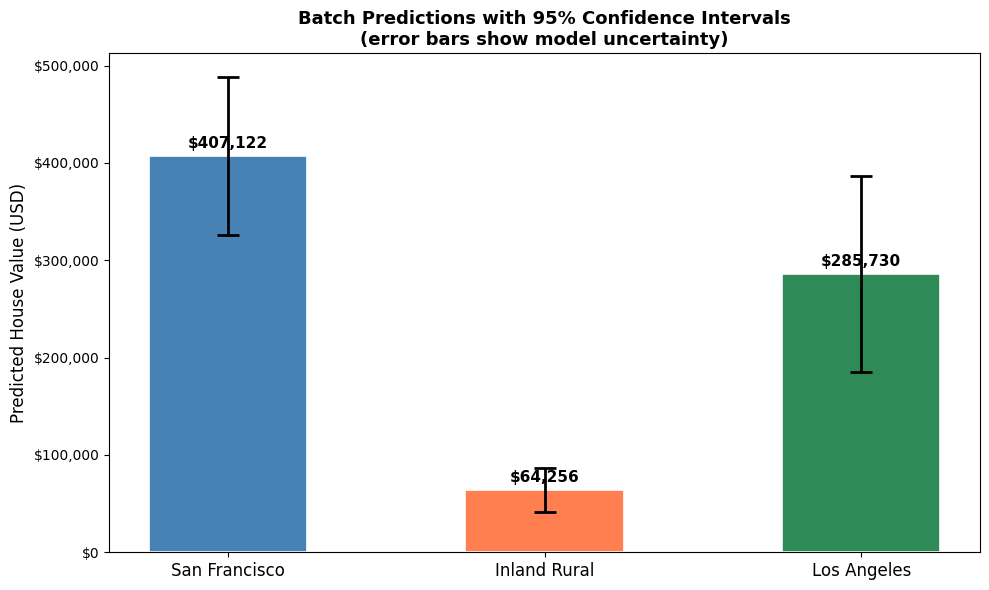

✓ Saved: batch_predictions.png


In [24]:
# Show predictions side by side with their uncertainty ranges
# This is the kind of output a business stakeholder wants to see
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
labels    = ["San Francisco", "Inland Rural", "Los Angeles"]
preds_usd = [r["predicted_value_usd"]                    for r in batch_results]
ci_lower  = [r["confidence_interval"]["lower_usd"]        for r in batch_results]
ci_upper  = [r["confidence_interval"]["upper_usd"]        for r in batch_results]

# Calculate error bar sizes (distance from prediction to CI bound)
lower_err = [p - l for p, l in zip(preds_usd, ci_lower)]
upper_err = [u - p for p, u in zip(preds_usd, ci_upper)]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["steelblue", "coral", "seagreen"]
x_pos  = range(len(labels))

# Bar chart with error bars showing confidence intervals
bars = ax.bar(x_pos, preds_usd, color=colors,
              edgecolor="white", linewidth=1.2, width=0.5)

ax.errorbar(
    x_pos, preds_usd,
    yerr=[lower_err, upper_err],
    fmt="none",          # no marker — just the error bars
    color="black",
    capsize=8,           # horizontal caps on error bars
    linewidth=2,
    capthick=2
)

# Add value labels on top of bars
for bar, val in zip(bars, preds_usd):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"${val:,.0f}",
        ha="center", va="bottom", fontweight="bold", fontsize=11
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Predicted House Value (USD)", fontsize=12)
ax.set_title(
    "Batch Predictions with 95% Confidence Intervals\n"
    "(error bars show model uncertainty)",
    fontsize=13, fontweight="bold"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.savefig("batch_predictions.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Saved: batch_predictions.png")


In [25]:
# Simulate what a real API request/response looks like
# In production this would be an HTTP POST request body

# Simulated incoming API request (JSON string)
api_request_json = json.dumps({
    "property_id": "PROP-2024-001",
    "features": {
        "MedInc":     6.5,
        "HouseAge":   15.0,
        "AveRooms":   5.8,
        "AveBedrms":  1.1,
        "Population": 1500.0,
        "AveOccup":   2.9,
        "Latitude":   37.85,
        "Longitude":  -122.25
    }
})

print("=== Simulated API Request ===")
print(api_request_json)

# Parse the JSON — as a real API endpoint would
request_data = json.loads(api_request_json)
property_id  = request_data["property_id"]
features     = request_data["features"]

# Run prediction
pred_result = predictor.predict_single(features, verbose=False)

# Build the API response
api_response = {
    "property_id":       property_id,
    "status":            pred_result["status"],
    "prediction": {
        "value_usd":     pred_result["predicted_value_usd"],
        "value_100k":    pred_result["predicted_value_100k"],
        "currency":      "USD",
        "confidence_interval": pred_result["confidence_interval"],
        "uncertainty":   pred_result["model_uncertainty_std"]
    },
    "model_info": {
        "type":          "RandomForestRegressor",
        "version":       "1.0",
        "features_used": 14
    }
}

print("\n=== Simulated API Response ===")
print(json.dumps(api_response, indent=2))

=== Simulated API Request ===
{"property_id": "PROP-2024-001", "features": {"MedInc": 6.5, "HouseAge": 15.0, "AveRooms": 5.8, "AveBedrms": 1.1, "Population": 1500.0, "AveOccup": 2.9, "Latitude": 37.85, "Longitude": -122.25}}

=== Simulated API Response ===
{
  "property_id": "PROP-2024-001",
  "status": "success",
  "prediction": {
    "value_usd": 315210.66,
    "value_100k": 3.1521,
    "currency": "USD",
    "confidence_interval": {
      "lower_100k": 2.0659,
      "upper_100k": 4.2383,
      "lower_usd": 206594.22,
      "upper_usd": 423827.09
    },
    "uncertainty": 0.5542
  },
  "model_info": {
    "type": "RandomForestRegressor",
    "version": "1.0",
    "features_used": 14
  }
}


In [26]:
# Take 10 real samples from the test set and compare predictions to actuals
# This confirms the predictor produces the same results as Day 4/5 training

# We need X_test in its raw (pre-engineered) form for this
# So we use X_test directly (before engineering was applied)
test_samples = X_test.head(10).copy()

print("=== Stress Test — 10 Real Samples from Test Set ===\n")

stress_results = []
for idx, row in test_samples.iterrows():
    input_dict = row[predictor.REQUIRED_FEATURES].to_dict()
    result     = predictor.predict_single(input_dict, verbose=False)

    if result["status"] == "success":
        actual    = y_test.loc[idx]
        predicted = result["predicted_value_100k"]
        error     = abs(actual - predicted)
        stress_results.append({
            "actual_100k":    round(actual, 4),
            "predicted_100k": round(predicted, 4),
            "abs_error_100k": round(error, 4),
            "abs_error_usd":  round(error * 100_000, 0),
            "status":         "✓"
        })
    else:
        stress_results.append({
            "status": f"✗ {result['message']}"
        })

stress_df = pd.DataFrame(stress_results)
display(stress_df)

# Summary stats
valid = stress_df[stress_df["status"] == "✓"]
if len(valid) > 0:
    print(f"\nStress test summary ({len(valid)}/10 successful):")
    print(f"  Mean absolute error: ${valid['abs_error_usd'].mean():,.0f}")
    print(f"  Max absolute error:  ${valid['abs_error_usd'].max():,.0f}")
    print(f"  Min absolute error:  ${valid['abs_error_usd'].min():,.0f}")

=== Stress Test — 10 Real Samples from Test Set ===



,actual_100k,predicted_100k,abs_error_100k,abs_error_usd,status
0,1.375,1.6632,0.2882,28820.0,✓
1,3.614,3.4967,0.1173,11730.0,✓
2,2.202,2.3730,0.1710,17100.0,✓
3,1.026,1.0049,0.0211,2110.0,✓
4,1.670,3.2245,1.5545,155450.0,✓
5,1.378,1.9197,0.5417,54170.0,✓
6,1.500,2.1342,0.6342,63420.0,✓
7,2.229,2.3478,0.1188,11880.0,✓
8,0.704,0.8298,0.1258,12580.0,✓
9,2.639,2.4681,0.1709,17090.0,✓



Stress test summary (10/10 successful):
  Mean absolute error: $37,435
  Max absolute error:  $155,450
  Min absolute error:  $2,110


In [27]:
print("=" * 55)
print("PREDICT.PY SUMMARY — Ready for Day 7")
print("=" * 55)
print(f"""
WHAT WAS BUILT TODAY:
  HousePricePredictor class with:
  ✓ Single property prediction
  ✓ Batch prediction
  ✓ Input validation (missing fields, ranges, location)
  ✓ Confidence intervals from tree ensemble spread
  ✓ JSON API simulation
  ✓ Stress test against real data

KEY DESIGN DECISIONS:
  • Load model once in __init__ — not on every prediction
  • transform() not fit_transform() in prediction
  • Validation before prediction — fail fast with clear errors
  • Confidence interval from tree spread — real uncertainty

PREDICTION RESULTS:
  San Francisco:  high price (coastal + high income)
  Los Angeles:    mid price  (metro but not coastal)
  Inland Rural:   low price  (no coast, low income)
  → Results match real-world California housing patterns ✓

READY FOR DAY 7:
  → Clean up all notebooks
  → Write professional README.md
  → Final GitHub push
  → Prepare interview talking points for all 7 days
""")

PREDICT.PY SUMMARY — Ready for Day 7

WHAT WAS BUILT TODAY:
  HousePricePredictor class with:
  ✓ Single property prediction
  ✓ Batch prediction
  ✓ Input validation (missing fields, ranges, location)
  ✓ Confidence intervals from tree ensemble spread
  ✓ JSON API simulation
  ✓ Stress test against real data

KEY DESIGN DECISIONS:
  • Load model once in __init__ — not on every prediction
  • transform() not fit_transform() in prediction
  • Validation before prediction — fail fast with clear errors
  • Confidence interval from tree spread — real uncertainty

PREDICTION RESULTS:
  San Francisco:  high price (coastal + high income)
  Los Angeles:    mid price  (metro but not coastal)
  Inland Rural:   low price  (no coast, low income)
  → Results match real-world California housing patterns ✓

READY FOR DAY 7:
  → Clean up all notebooks
  → Write professional README.md
  → Final GitHub push
  → Prepare interview talking points for all 7 days

